In [42]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [32]:
df = pd.read_csv("../data/train_clear.csv")

In [33]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [34]:
cat_cols = X.select_dtypes(include="string").columns

numeric_cols = X.select_dtypes(include="number").columns
num_cols = [col for col in numeric_cols if len(df[col].unique()) > 2]

In [35]:
X_encoded = X.copy()

In [36]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.int64)
X_encoded[cat_cols] = encoder.fit_transform(X_encoded[cat_cols].to_numpy())

In [37]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [38]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

In [39]:
def train_model(model, X, y):
    all_y_true = []
    all_y_pred = []
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train.to_numpy(), y_train)

        y_pred = model.predict(X_val.to_numpy())
        
        score = model.score(X_val.to_numpy(), y_val)
        cv_scores.append(score)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    scores = np.array(cv_scores)
    print(f"Точность {model}: {scores.mean():0.3f} ± {scores.std():0.3f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    disp_raw = ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        all_y_pred, 
        display_labels=le.classes_,
        ax=ax,
        normalize="true"
    )
    plt.xticks(rotation=45, ha='right')

Точность DecisionTreeClassifier(): 0.791 ± 0.003


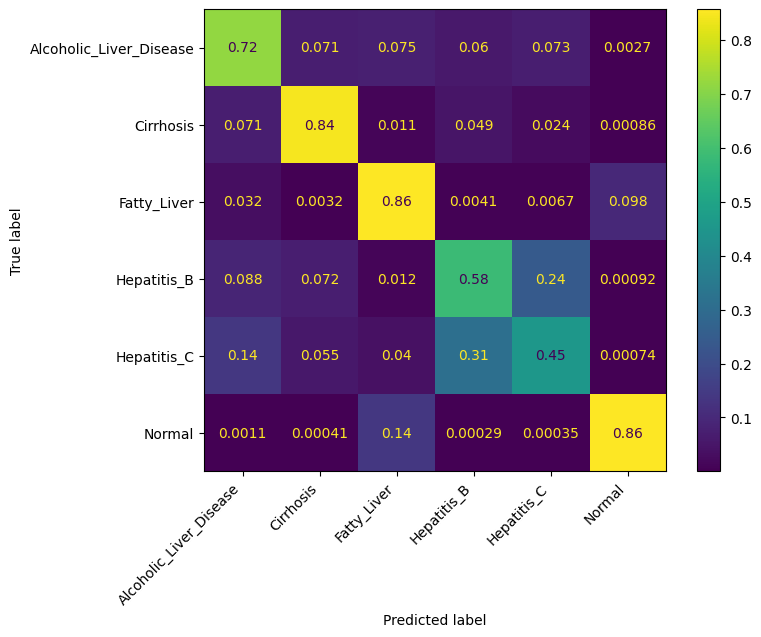

In [ ]:
tree = DecisionTreeClassifier()
train_model(tree, X_encoded, y_encoded)

Точность RandomForestClassifier(): 0.825 ± 0.033


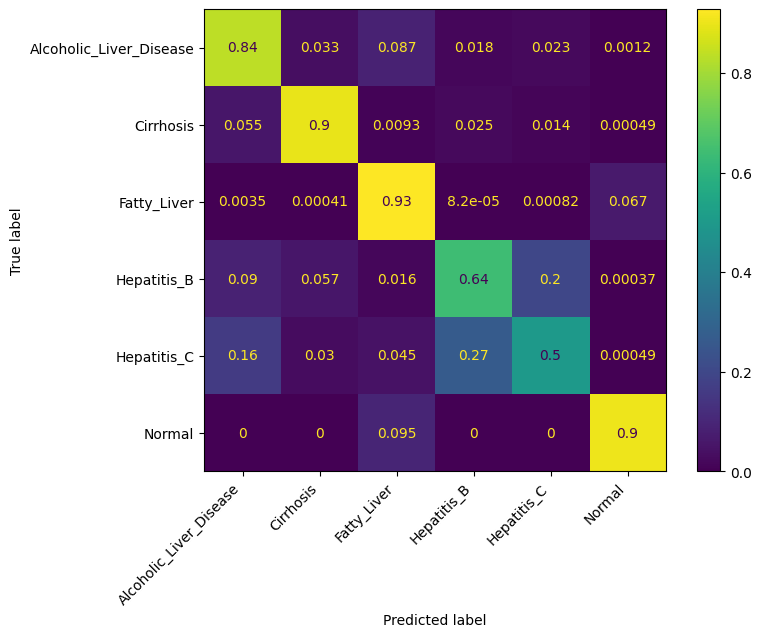

In [43]:
forest = RandomForestClassifier()
train_model(forest, X_encoded, y_encoded)

In [50]:
importance_df = pd.DataFrame(
    {"feature": X_encoded.columns, "importance": forest.feature_importances_}
).sort_values("importance", ascending=False)

print(importance_df.head(20))

               feature  importance
22           Bilirubin    0.146001
21                 AST    0.145471
20                 ALT    0.132901
23             Albumin    0.072144
11        Sym_Jaundice    0.060382
24           Platelets    0.059583
10         Sym_Fatigue    0.055801
15      Sym_Dark_Urine    0.044090
27      De_Ritis_ratio    0.039939
17     Comorb_Diabetes    0.028197
14         Sym_Ascites    0.027596
3                  BMI    0.022938
7          Sleep_Hours    0.021431
0                  Age    0.021371
25     Alk_Phosphatase    0.020301
12  Sym_Abdominal_Pain    0.018544
2           Occupation    0.013422
13         Sym_Itching    0.010503
6    Physical_Activity    0.008299
16     Sym_Weight_Loss    0.007990
